In [1]:
import torch
import random
import numpy as np

# --------------------------------------------------
# Reproducibility Seed
# --------------------------------------------------

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seed set for reproducibility.")

Random seed set for reproducibility.


# *Loading Data*

In [2]:
train = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train"
test = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test"
validation = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation"

In [3]:
import os

def load_images_from_dirs(dir_list):
    all_images = []

    for directory in dir_list:
        for img in os.listdir(directory):
            img_path = os.path.join(directory, img)

            if os.path.isfile(img_path):
                all_images.append(img_path)

    return all_images

In [4]:
test_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/NeuralTextures"
]

test_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/real"
]

test_fake = load_images_from_dirs(test_fake_dirs)
test_real = load_images_from_dirs(test_real_dirs)

print(len(test_fake))
print(len(test_real))

2250
2250


In [5]:
train_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/NeuralTextures"
]

train_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/real"
]

train_fake = load_images_from_dirs(train_fake_dirs)
train_real = load_images_from_dirs(train_real_dirs)

print(len(train_fake))
print(len(train_real))

10500
10500


In [6]:
validation_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/NeuralTextures"
]

validation_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/real"
]

validation_fake = load_images_from_dirs(validation_fake_dirs)
validation_real = load_images_from_dirs(validation_real_dirs)

print(len(validation_fake))
print(len(validation_real))

2250
2250


# Data loaders 


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import time
import copy

class DeepfakeDataset(Dataset):
    def __init__(self, fake_paths, real_paths, transform=None):
        
        self.image_paths = fake_paths + real_paths
        self.labels = [1] * len(fake_paths) + [0] * len(real_paths)
        
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
IMG_SIZE = 299

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = DeepfakeDataset(
    train_fake,
    train_real,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    validation_fake,
    validation_real,
    transform=val_test_transform
)

test_dataset = DeepfakeDataset(
    test_fake,
    test_real,
    transform=val_test_transform
)

In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [11]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

21000
4500
4500
torch.Size([32, 3, 299, 299])
torch.Size([32])


# *Train Model Function*

In [12]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=25,
    patience=5,
    save_path="best_model.pth"
):

    since = time.time()

    # --------------------------------------------------------
    # AUTOMATIC DEVICE DETECTION
    # --------------------------------------------------------

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    # --------------------------------------------------------
    # BEST MODEL TRACKING
    # --------------------------------------------------------

    best_model_wts = copy.deepcopy(model.state_dict())

    best_acc = 0.0

    epochs_no_improve = 0

    early_stop = False

    # --------------------------------------------------------
    # HISTORY TRACKING
    # --------------------------------------------------------

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(num_epochs):

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # ====================================================
        # TRAIN + VALIDATION PHASES
        # ====================================================

        for phase in ['train', 'val']:

            if phase == 'train':

                model.train()

                dataloader = train_loader

            else:

                model.eval()

                dataloader = val_loader

            running_loss = 0.0

            running_corrects = 0

            # =================================================
            # ITERATE OVER DATA
            # =================================================

            for inputs, labels in dataloader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                # --------------------------------------------
                # ZERO GRADIENTS
                # --------------------------------------------

                optimizer.zero_grad()

                # --------------------------------------------
                # FORWARD PASS
                # --------------------------------------------

                with torch.set_grad_enabled(
                    phase == 'train'
                ):

                    outputs = model(inputs)

                    _, preds = torch.max(
                        outputs,
                        1
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                    # ----------------------------------------
                    # BACKWARD + OPTIMIZE
                    # ----------------------------------------

                    if phase == 'train':

                        loss.backward()

                        optimizer.step()

                # --------------------------------------------
                # STATISTICS
                # --------------------------------------------

                running_loss += (
                    loss.item() * inputs.size(0)
                )

                running_corrects += torch.sum(
                    preds == labels.data
                )

            # =================================================
            # EPOCH METRICS
            # =================================================

            epoch_loss = (
                running_loss / len(dataloader.dataset)
            )

            epoch_acc = (
                running_corrects.double()
                / len(dataloader.dataset)
            )

            print(
                f'{phase} Loss: '
                f'{epoch_loss:.4f} '
                f'Acc: {epoch_acc:.4f}'
            )

            history[f'{phase}_loss'].append(
                epoch_loss
            )

            history[f'{phase}_acc'].append(
                epoch_acc.item()
            )

            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if phase == 'val':

                if epoch_acc > best_acc:

                    best_acc = epoch_acc

                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

                    epochs_no_improve = 0

                    # ----------------------------------------
                    # SAVE BEST MODEL
                    # ----------------------------------------

                    torch.save(
                        model.state_dict(),
                        save_path
                    )

                    print(
                        "Best model saved."
                    )

                else:

                    epochs_no_improve += 1

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if epochs_no_improve == patience:

            print(
                f'Early stopping triggered '
                f'after {patience} epochs '
                f'with no improvement '
                f'in validation accuracy.'
            )

            early_stop = True

            break

        # ====================================================
        # CLEAR CUDA CACHE
        # ====================================================

        torch.cuda.empty_cache()

    # ========================================================
    # TRAINING COMPLETE
    # ========================================================

    time_elapsed = time.time() - since

    print(
        f'Training complete in '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )

    print(f'Best val Acc: {best_acc:.4f}')

    # ========================================================
    # LOAD BEST MODEL WEIGHTS
    # ========================================================

    model.load_state_dict(best_model_wts)

    return model, history

print(
    "Training function `train_model` defined. "
    "You can now call it normally."
)

Training function `train_model` defined. You can now call it normally.


# Exception Net Model - Baseline 3

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm # For XceptionNet

# Binary classification
num_classes = 2

print("Loading pretrained XceptionNet...")
# Load pretrained XceptionNet from timm
model_xception = timm.create_model('xception', pretrained=True)

# Freeze all layers first
# Comments explaining freezing layers
for param in model_xception.parameters():
    param.requires_grad = False

print("Freezing most backbone layers.")

# Unfreeze ONLY the final trainable layers using parameter slicing
# This is a more robust way to unfreeze the 'last few layers' without hardcoding names.
# We'll unfreeze the last 30 parameters of the entire model.
# Comments explaining unfreezing layers
for i, param in enumerate(list(model_xception.parameters())):
    if i >= (len(list(model_xception.parameters())) - 30): # Unfreeze the last 30 parameters
        param.requires_grad = True
        # print(f"Unfrozen parameter {i}") # Uncomment to see which parameters are unfrozen
print("Unfrozen the last 30 parameters for fine-tuning.")

# Get classifier input features
# timm models usually have a `num_features` attribute for the feature extractor output
num_ftrs_xception = model_xception.num_features

# Custom classifier head similar to EfficientNet baseline
# Comments explaining classifier replacement
# For timm's Xception, the correct attribute to replace the classifier head is typically `model.classifier`.
# The structure of the head needs to match the EfficientNet baseline:
# (Dropout, Linear, ReLU, Dropout, Linear, ReLU, Dropout, Linear output)
model_xception.classifier = nn.Sequential(
    nn.Dropout(0.4), # Initial dropout as seen in EfficientNet baseline
    nn.Linear(num_ftrs_xception, 512),
    nn.ReLU(),

    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),

    nn.Dropout(0.2),
    nn.Linear(128, num_classes)
)

print("Replaced classifier head with a custom 3-layer head on `model_xception.classifier`.")

# Define loss function and optimizer
criterion_xception = nn.CrossEntropyLoss()
optimizer_xception = optim.Adam(
    filter(lambda p: p.requires_grad, model_xception.parameters()),
    lr=0.0001
)

# Move model to GPU if available (device is defined in previous cells)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_xception = model_xception.to(device)

print(f"XceptionNet model moved to: {device}")
print("Loss function (CrossEntropyLoss) and optimizer (Adam) initialized for XceptionNet.")
print("XceptionNet fine-tuned with 3-layer classifier head.")

Loading pretrained XceptionNet...


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Freezing most backbone layers.
Unfrozen the last 30 parameters for fine-tuning.
Replaced classifier head with a custom 3-layer head on `model_xception.classifier`.
XceptionNet model moved to: cuda:0
Loss function (CrossEntropyLoss) and optimizer (Adam) initialized for XceptionNet.
XceptionNet fine-tuned with 3-layer classifier head.


In [14]:
print("\n--- Starting training for XceptionNet baseline ---")

model_xception_ft, hist_xception = train_model(
    model_xception,
    criterion_xception,
    optimizer_xception,
    train_loader,
    val_loader,
    num_epochs=30,
    patience=5,
    save_path="best_xception_model.pth"
)

print("\nTraining complete for XceptionNet baseline.")
print("Best model saved to: best_xception_model.pth")



--- Starting training for XceptionNet baseline ---
Epoch 1/30
----------
train Loss: 0.7786 Acc: 0.6835
val Loss: 0.5538 Acc: 0.7269
Best model saved.
Epoch 2/30
----------
train Loss: 0.4223 Acc: 0.8046
val Loss: 0.5359 Acc: 0.7489
Best model saved.
Epoch 3/30
----------
train Loss: 0.3360 Acc: 0.8535
val Loss: 0.6277 Acc: 0.7380
Epoch 4/30
----------
train Loss: 0.2833 Acc: 0.8819
val Loss: 0.5618 Acc: 0.7747
Best model saved.
Epoch 5/30
----------
train Loss: 0.2393 Acc: 0.8985
val Loss: 0.6043 Acc: 0.7671
Epoch 6/30
----------
train Loss: 0.2090 Acc: 0.9149
val Loss: 0.6842 Acc: 0.7507
Epoch 7/30
----------
train Loss: 0.1859 Acc: 0.9238
val Loss: 0.6207 Acc: 0.7922
Best model saved.
Epoch 8/30
----------
train Loss: 0.1685 Acc: 0.9310
val Loss: 0.6793 Acc: 0.7780
Epoch 9/30
----------
train Loss: 0.1490 Acc: 0.9437
val Loss: 0.6802 Acc: 0.7827
Epoch 10/30
----------
train Loss: 0.1407 Acc: 0.9438
val Loss: 0.6786 Acc: 0.7749
Epoch 11/30
----------
train Loss: 0.1351 Acc: 0.9471
v

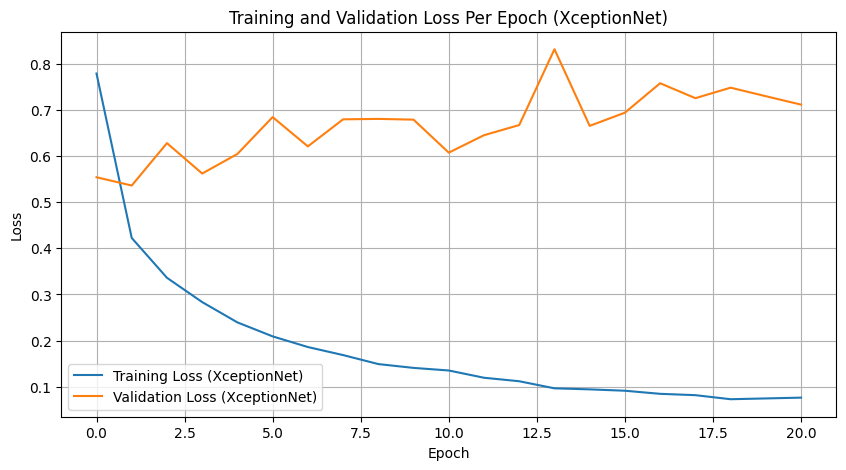

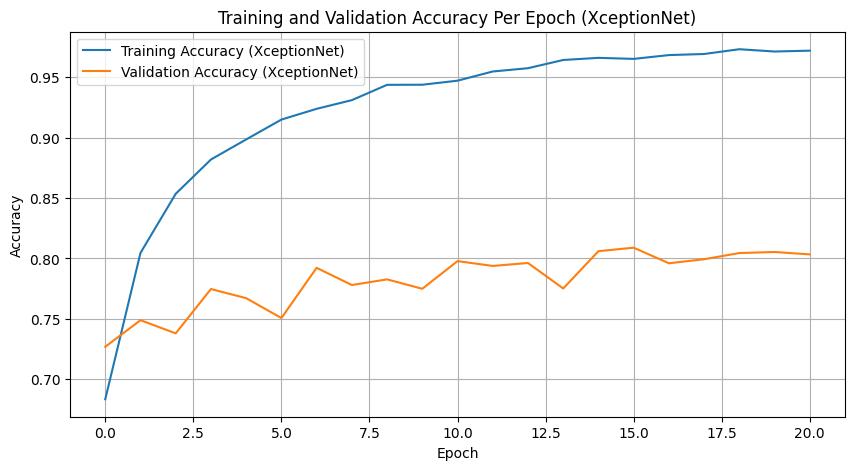


Evaluating XceptionNet model on test dataset...


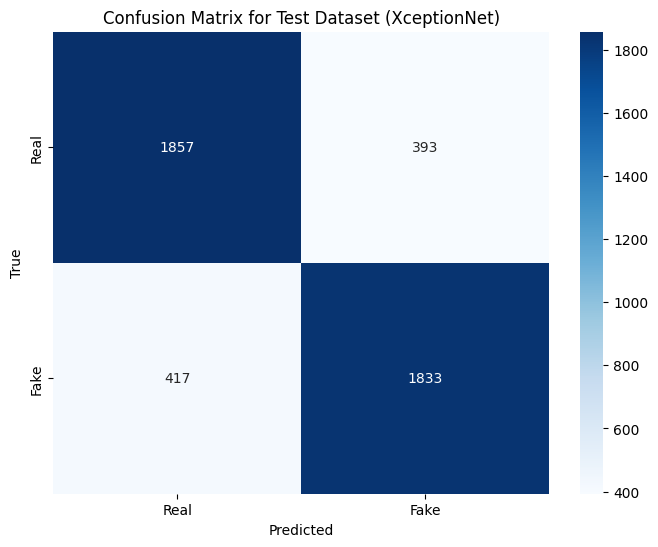


Test Accuracy (XceptionNet): 0.8200
Test Precision (XceptionNet): 0.8235
Test Recall (XceptionNet): 0.8147
Test F1-Score (XceptionNet): 0.8190

Generating ROC curve data for XceptionNet model...


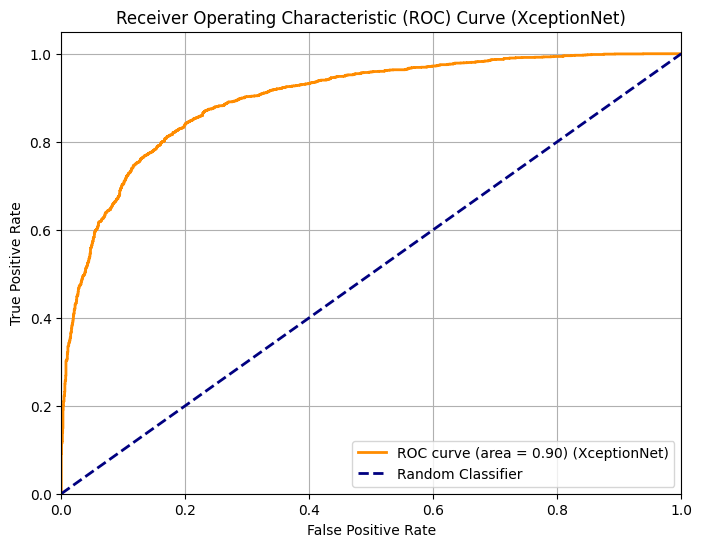

Area Under the Curve (AUC) (XceptionNet): 0.8982


In [15]:
import matplotlib.pyplot as plt

import torch

def to_float(x):
    return x.cpu().item() if isinstance(x, torch.Tensor) else float(x)

hist_xception['train_acc'] = [to_float(acc) for acc in hist_xception['train_acc']]
hist_xception['val_acc']   = [to_float(acc) for acc in hist_xception['val_acc']]

plt.figure(figsize=(10, 5))
plt.plot(hist_xception['train_loss'], label='Training Loss (XceptionNet)')
plt.plot(hist_xception['val_loss'], label='Validation Loss (XceptionNet)')
plt.title('Training and Validation Loss Per Epoch (XceptionNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hist_xception['train_acc'], label='Training Accuracy (XceptionNet)')
plt.plot(hist_xception['val_acc'], label='Validation Accuracy (XceptionNet)')
plt.title('Training and Validation Accuracy Per Epoch (XceptionNet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import seaborn as sns

model_xception_ft.eval()

all_labels_xception = []
all_preds_xception = []

print("\nEvaluating XceptionNet model on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_xception_ft(inputs)
        _, preds = torch.max(outputs, 1)

        all_labels_xception.extend(labels.cpu().numpy())
        all_preds_xception.extend(preds.cpu().numpy())

all_labels_xception = np.array(all_labels_xception)
all_preds_xception = np.array(all_preds_xception)

cm_xception = confusion_matrix(all_labels_xception, all_preds_xception)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xception, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Test Dataset (XceptionNet)')
plt.show()

accuracy_xception = accuracy_score(all_labels_xception, all_preds_xception)
precision_xception = precision_score(all_labels_xception, all_preds_xception, average='binary')
recall_xception = recall_score(all_labels_xception, all_preds_xception, average='binary')
f1_xception = f1_score(all_labels_xception, all_preds_xception, average='binary')

print(f"\nTest Accuracy (XceptionNet): {accuracy_xception:.4f}")
print(f"Test Precision (XceptionNet): {precision_xception:.4f}")
print(f"Test Recall (XceptionNet): {recall_xception:.4f}")
print(f"Test F1-Score (XceptionNet): {f1_xception:.4f}")

# --- Generating ROC curve for XceptionNet Model ---
print("\nGenerating ROC curve data for XceptionNet model...")

all_labels_roc_xception = []
all_probs_roc_xception = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_xception_ft(inputs)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels_roc_xception.extend(labels.cpu().numpy())
        all_probs_roc_xception.extend(probabilities[:, 1].cpu().numpy())

fpr_xception, tpr_xception, thresholds_xception = roc_curve(all_labels_roc_xception, all_probs_roc_xception)
roc_auc_xception = auc(fpr_xception, tpr_xception)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xception, tpr_xception, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_xception:.2f}) (XceptionNet)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (XceptionNet)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC) (XceptionNet): {roc_auc_xception:.4f}")

# Augumented Model - Exception Net - Baseline Model 4

In [17]:
import random
import torch

class SimulateJPEGCompression(object):
    def __init__(self, quality_range=(80, 95), p=0.15):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            quality = random.randint(self.quality_range[0], self.quality_range[1])
            tensor = (torch.round(tensor * quality) / quality)
        return tensor


class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.01, p=0.1):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            tensor = tensor + noise
            tensor = torch.clamp(tensor, 0., 1.)
        return tensor

print("Custom augmentation classes defined: SimulateJPEGCompression, AddGaussianNoise")


Custom augmentation classes defined: SimulateJPEGCompression, AddGaussianNoise


In [18]:
# SimulateJPEGCompression and AddGaussianNoise are defined above.

train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
        saturation=0.05,
        hue=0.02
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.1),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.01, p=0.1),
    SimulateJPEGCompression(quality_range=(80, 95), p=0.15),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_aug = DeepfakeDataset(
    train_fake,
    train_real,
    transform=train_transform_aug
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print("Augmented XceptionNet data loader ready.")


Augmented XceptionNet data loader ready.


In [19]:
print("\n--- Starting Augmented XceptionNet Training ---")

# Re-instantiate XceptionNet so augmented training starts from pretrained weights,
# not from the already fine-tuned model_xception_ft.
import timm
model_aug = timm.create_model('xception', pretrained=True)
for param in model_aug.parameters():
    param.requires_grad = False
params = list(model_aug.parameters())
for param in params[max(0, len(params)-30):]:
    param.requires_grad = True
num_ftrs_aug = model_aug.num_features
model_aug.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs_aug, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(
    filter(lambda p: p.requires_grad, model_aug.parameters()),
    lr=0.0001
)
model_aug = model_aug.to(device)
print("Fresh XceptionNet instantiated for augmented training.")

model_aug, hist_aug = train_model(
    model_aug,
    criterion_aug,
    optimizer_aug,
    train_loader_aug ,
    val_loader,
    num_epochs=30,
    patience=5
)

print("\nTraining complete for Augmented XceptionNet.")



--- Starting Augmented XceptionNet Training ---


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Fresh XceptionNet instantiated for augmented training.
Epoch 1/30
----------
train Loss: 0.7935 Acc: 0.6730
val Loss: 0.5611 Acc: 0.7191
Best model saved.
Epoch 2/30
----------
train Loss: 0.4481 Acc: 0.7892
val Loss: 0.5284 Acc: 0.7547
Best model saved.
Epoch 3/30
----------
train Loss: 0.3690 Acc: 0.8371
val Loss: 0.5159 Acc: 0.7731
Best model saved.
Epoch 4/30
----------
train Loss: 0.3141 Acc: 0.8637
val Loss: 0.5278 Acc: 0.7727
Epoch 5/30
----------
train Loss: 0.2769 Acc: 0.8843
val Loss: 0.5178 Acc: 0.7800
Best model saved.
Epoch 6/30
----------
train Loss: 0.2443 Acc: 0.8959
val Loss: 0.6014 Acc: 0.7856
Best model saved.
Epoch 7/30
----------
train Loss: 0.2132 Acc: 0.9118
val Loss: 0.6107 Acc: 0.7729
Epoch 8/30
----------
train Loss: 0.2039 Acc: 0.9167
val Loss: 0.6030 Acc: 0.7747
Epoch 9/30
----------
train Loss: 0.1843 Acc: 0.9251
val Loss: 0.5994 Acc: 0.7933
Best model saved.
Epoch 10/30
----------
train Loss: 0.1726 Acc: 0.9308
val Loss: 0.6716 Acc: 0.7749
Epoch 11/30
----


--- Plotting Training and Validation History for Augmented XceptionNet Model ---


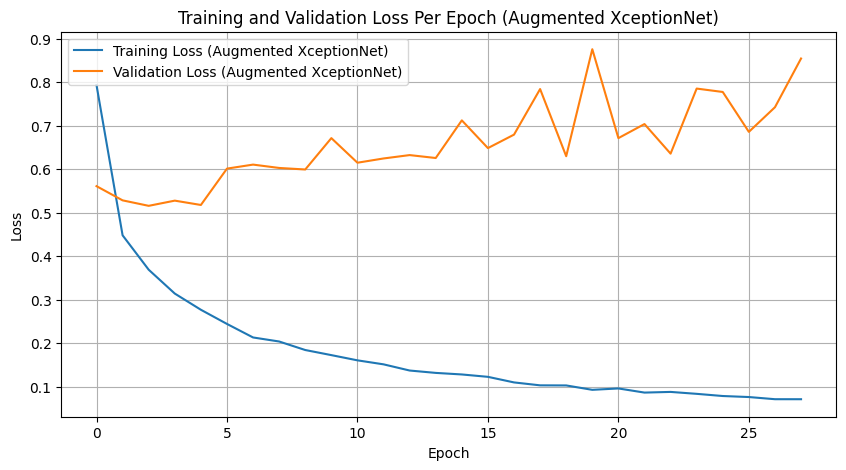

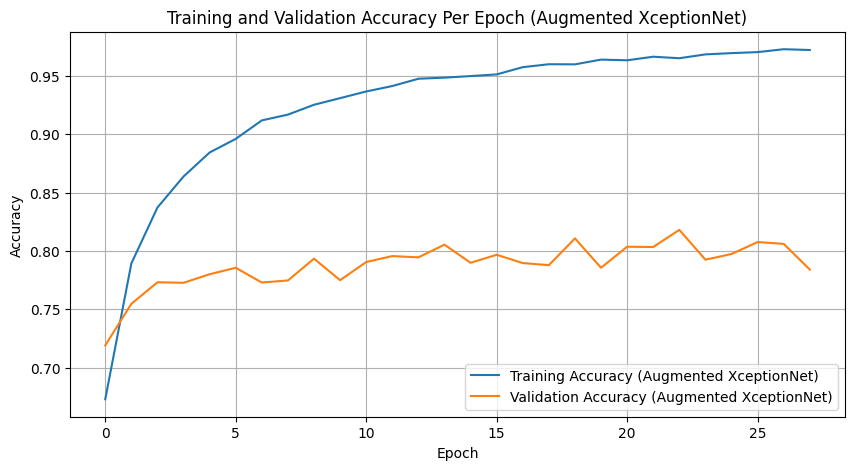


Evaluating Augmented XceptionNet model on test dataset...


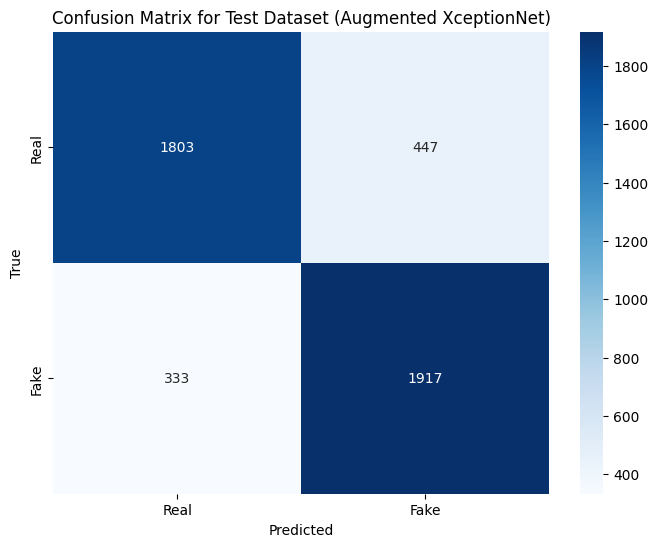


Test Accuracy (Augmented XceptionNet): 0.8267
Test Precision (Augmented XceptionNet): 0.8109
Test Recall (Augmented XceptionNet): 0.8520
Test F1-Score (Augmented XceptionNet): 0.8309

Generating ROC curve data for Augmented XceptionNet model...


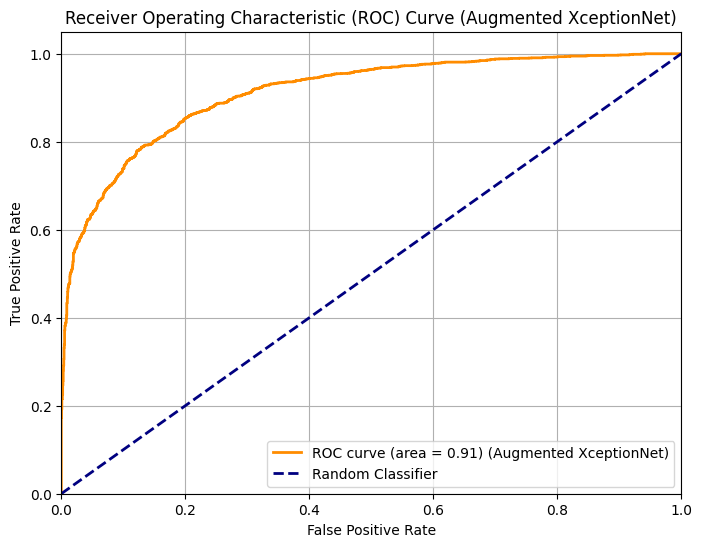

Area Under the Curve (AUC) (Augmented XceptionNet): 0.9112


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import torch

# --- Plotting Training and Validation History for Augmented XceptionNet Model ---
print("\n--- Plotting Training and Validation History for Augmented XceptionNet Model ---")

# Convert accuracy tensors to CPU numbers for plotting if they are still tensors
if isinstance(hist_aug['train_acc'][0], torch.Tensor):
    hist_aug['train_acc'] = [acc.cpu().item() for acc in hist_aug['train_acc']]
if isinstance(hist_aug['val_acc'][0], torch.Tensor):
    hist_aug['val_acc'] = [acc.cpu().item() for acc in hist_aug['val_acc']]

plt.figure(figsize=(10, 5))
plt.plot(hist_aug['train_loss'], label='Training Loss (Augmented XceptionNet)')
plt.plot(hist_aug['val_loss'], label='Validation Loss (Augmented XceptionNet)')
plt.title('Training and Validation Loss Per Epoch (Augmented XceptionNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hist_aug['train_acc'], label='Training Accuracy (Augmented XceptionNet)')
plt.plot(hist_aug['val_acc'], label='Validation Accuracy (Augmented XceptionNet)')
plt.title('Training and Validation Accuracy Per Epoch (Augmented XceptionNet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Evaluation on Test Dataset for Augmented XceptionNet Model ---
model_aug.eval()

all_labels_aug = []
all_preds_aug = []

print("\nEvaluating Augmented XceptionNet model on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_aug(inputs)
        _, preds = torch.max(outputs, 1)

        all_labels_aug.extend(labels.cpu().numpy())
        all_preds_aug.extend(preds.cpu().numpy())

all_labels_aug = np.array(all_labels_aug)
all_preds_aug = np.array(all_preds_aug)

# --- Plotting Confusion Matrix for Augmented XceptionNet Model ---
cm_aug = confusion_matrix(all_labels_aug, all_preds_aug)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Test Dataset (Augmented XceptionNet)')
plt.show()

# Calculate and print other metrics
accuracy_aug = accuracy_score(all_labels_aug, all_preds_aug)
precision_aug = precision_score(all_labels_aug, all_preds_aug, average='binary')
recall_aug = recall_score(all_labels_aug, all_preds_aug, average='binary')
f1_aug = f1_score(all_labels_aug, all_preds_aug, average='binary')

print(f"\nTest Accuracy (Augmented XceptionNet): {accuracy_aug:.4f}")
print(f"Test Precision (Augmented XceptionNet): {precision_aug:.4f}")
print(f"Test Recall (Augmented XceptionNet): {recall_aug:.4f}")
print(f"Test F1-Score (Augmented XceptionNet): {f1_aug:.4f}")

# --- Generating ROC curve for Augmented XceptionNet Model ---
print("\nGenerating ROC curve data for Augmented XceptionNet model...")

all_labels_roc_aug = []
all_probs_roc_aug = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_aug(inputs)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels_roc_aug.extend(labels.cpu().numpy())
        # We need the probability of the positive class (class 1, 'real')
        all_probs_roc_aug.extend(probabilities[:, 1].cpu().numpy())

fpr_aug, tpr_aug, thresholds_aug = roc_curve(all_labels_roc_aug, all_probs_roc_aug)
roc_auc_aug = auc(fpr_aug, tpr_aug)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_aug, tpr_aug, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_aug:.2f}) (Augmented XceptionNet)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Augmented XceptionNet)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC) (Augmented XceptionNet): {roc_auc_aug:.4f}")